# Transformer on V-JEPA embeddings — multi-label diagnostic super-classes on PTB-XL

Same Transformer architecture as the binary notebook, but now the output head emits 5 logits, one per PTB-XL diagnostic super-class:

- **NORM** — normal ECG
- **MI** — myocardial infarction
- **STTC** — ST/T changes
- **CD** — conduction disturbance
- **HYP** — hypertrophy

Each record can belong to several super-classes simultaneously (multi-label), so the loss is `BCEWithLogitsLoss` with class-balanced `pos_weight`. Thresholds are tuned per class on fold 9; final metrics are reported on fold 10.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'src').is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
print('Repo root:', REPO_ROOT)
print('Source dir on sys.path:', SRC_DIR)

Repo root: /Users/paolodeidda/Documents/UNI/Master/sem4/Comp Vision/CV_group_J
Source dir on sys.path: /Users/paolodeidda/Documents/UNI/Master/sem4/Comp Vision/CV_group_J/src


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

from transformer_vjepa.transformer_vjepa_multilabel import (
    ensure_ptbxl_metadata,
    load_scp_to_super_class,
    load_multilabel_lookup,
    load_clip_sequences_multilabel,
    split_sequences_by_strat_fold,
    TransformerVJEPAMultiLabel,
    train_model,
    evaluate_model,
    SUPER_CLASSES,
)
from transformer_vjepa.transformer_vjepa_binary import resolve_device

device = resolve_device('auto')
print('Device:', device)
print('Super-classes:', SUPER_CLASSES)

Device: mps
Super-classes: ('NORM', 'MI', 'STTC', 'CD', 'HYP')


## 1. Build multi-label dataset

We re-derive the 5-d super-class label vector for every record by combining the `scp_codes` column in `ptbxl_database.csv` with the `diagnostic_class` mapping in `scp_statements.csv`. Records without any diagnostic super-class are skipped.

In [3]:
CLIP_CACHE_DIR = REPO_ROOT / 'src' / 'data' / 'ptbxl_vjepa_clip_embedding_experiments' / 'records'
PTBXL_DATA_DIR = REPO_ROOT / 'src' / 'data' / 'ptbxl'

assert CLIP_CACHE_DIR.is_dir(), (
    f'Missing clip embedding cache: {CLIP_CACHE_DIR}. '
    'Drop the .npz files you downloaded from Kun into this folder.'
)

PTBXL_DATA_DIR = ensure_ptbxl_metadata(PTBXL_DATA_DIR)
scp_to_super = load_scp_to_super_class(PTBXL_DATA_DIR / 'scp_statements.csv')
label_lookup = load_multilabel_lookup(PTBXL_DATA_DIR / 'ptbxl_database.csv', scp_to_super)
print(f'SCP codes mapped to a super-class: {len(scp_to_super)}')
print(f'Records with at least one diagnostic super-class label: {len(label_lookup)}')

sequences = load_clip_sequences_multilabel(CLIP_CACHE_DIR, label_lookup)
splits = split_sequences_by_strat_fold(sequences)

for split_name, items in splits.items():
    labels = np.stack([item.label for item in items], axis=0)
    per_class = dict(zip(SUPER_CLASSES, labels.sum(axis=0).astype(int).tolist()))
    print(f'{split_name}: {len(items)} sequences | per-class positives={per_class}')

sample = splits['train'][0]
print(f"\nExample sequence: record={sample.record_name} num_clips={sample.clip_embeddings.shape[0]} "
      f"embedding_dim={sample.clip_embeddings.shape[1]} label={sample.label.astype(int).tolist()}")

SCP codes mapped to a super-class: 44
Records with at least one diagnostic super-class label: 21388
train: 17084 sequences | per-class positives={'NORM': 7596, 'MI': 4379, 'STTC': 4186, 'CD': 3907, 'HYP': 2119}
val: 2146 sequences | per-class positives={'NORM': 955, 'MI': 540, 'STTC': 528, 'CD': 495, 'HYP': 268}
test: 2158 sequences | per-class positives={'NORM': 963, 'MI': 550, 'STTC': 521, 'CD': 496, 'HYP': 262}

Example sequence: record=1 num_clips=6 embedding_dim=1024 label=[1, 0, 0, 0, 0]


## 2. Build the multi-label Transformer

In [4]:
embedding_dim = int(splits['train'][0].clip_embeddings.shape[1])
model = TransformerVJEPAMultiLabel(
    embedding_dim=embedding_dim,
    model_dim=256,
    num_heads=8,
    num_layers=4,
    ffn_dim=1024,
    dropout=0.1,
    max_clips=32,
)
print(f'Model parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M')
print(f'Output head: Linear({256}, {len(SUPER_CLASSES)})')

Model parameters: 3.42M
Output head: Linear(256, 5)


## 3. Train

AdamW + cosine annealing, gradient clipping at 1.0, `BCEWithLogitsLoss` with per-class `pos_weight = neg/pos` computed from the training fold. Early stopping on validation **macro-AUC** (patience 10).

In [5]:
model, history, best_state = train_model(
    model,
    splits['train'],
    splits['val'],
    device=device,
    batch_size=32,
    epochs=60,
    lr=1e-4,
    weight_decay=1e-4,
    patience=10,
    seed=42,
    verbose=True,
)
print(f"\nBest epoch: {history.best_epoch} (val macro-AUC = {history.best_val_macro_auc:.4f})")

epoch=001 train_loss=0.9937 val_loss=0.9106 val_macro_auc=0.7389 val_macro_f1@0.5=0.5069
epoch=002 train_loss=0.9176 val_loss=0.8772 val_macro_auc=0.7537 val_macro_f1@0.5=0.5214
epoch=003 train_loss=0.9005 val_loss=0.8725 val_macro_auc=0.7543 val_macro_f1@0.5=0.5265
epoch=004 train_loss=0.8840 val_loss=0.9340 val_macro_auc=0.7515 val_macro_f1@0.5=0.4595
epoch=005 train_loss=0.8697 val_loss=0.8876 val_macro_auc=0.7581 val_macro_f1@0.5=0.5105
epoch=006 train_loss=0.8760 val_loss=0.8892 val_macro_auc=0.7706 val_macro_f1@0.5=0.5164
epoch=007 train_loss=0.8636 val_loss=0.8555 val_macro_auc=0.7705 val_macro_f1@0.5=0.5188
epoch=008 train_loss=0.8648 val_loss=0.9192 val_macro_auc=0.7663 val_macro_f1@0.5=0.4734
epoch=009 train_loss=0.8621 val_loss=0.8431 val_macro_auc=0.7736 val_macro_f1@0.5=0.5357
epoch=010 train_loss=0.8556 val_loss=0.8475 val_macro_auc=0.7755 val_macro_f1@0.5=0.5408
epoch=011 train_loss=0.8483 val_loss=0.9442 val_macro_auc=0.7638 val_macro_f1@0.5=0.4666
epoch=012 train_loss=

## 4. Evaluate on fold 10

Per-class thresholds are tuned on the validation fold (9) to maximize per-class F1, then applied to the test fold (10).

In [6]:
results = evaluate_model(
    model,
    splits['val'],
    splits['test'],
    device=device,
    batch_size=32,
)

print(f"Tuned thresholds: {results['thresholds']}")
print(f"\nTest macro-AUC: {results['test_macro_auc']:.4f}")
print(f"Test macro-F1: {results['test_macro_f1']:.4f}")
print('\nPer-class on test (fold 10):')
print(f"  {'class':<6} {'AUC':>6} {'AP':>6} {'P':>6} {'R':>6} {'F1':>6} {'support':>8} {'thr':>5}")
for row in results['test_per_class_report']:
    auc_text = f"{row['auc']:.4f}" if row['auc'] is not None else '  n/a'
    print(
        f"  {row['class']:<6} {auc_text:>6} {row['ap']:.4f} "
        f"{row['precision']:.3f} {row['recall']:.3f} {row['f1']:.3f} "
        f"{row['support']:>8} {row['threshold']:>5.2f}"
    )

Tuned thresholds: {'NORM': 0.5, 'MI': 0.44999998807907104, 'STTC': 0.44999998807907104, 'CD': 0.44999998807907104, 'HYP': 0.550000011920929}

Test macro-AUC: 0.7955
Test macro-F1: 0.5731

Per-class on test (fold 10):
  class     AUC     AP      P      R     F1  support   thr
  NORM   0.8526 0.7846 0.682 0.888 0.772      963  0.50
  MI     0.7402 0.4932 0.434 0.682 0.530      550  0.45
  STTC   0.8543 0.6422 0.513 0.820 0.631      521  0.45
  CD     0.7536 0.6003 0.504 0.556 0.529      496  0.45
  HYP    0.7765 0.3963 0.331 0.519 0.404      262  0.55


## 5. Plots

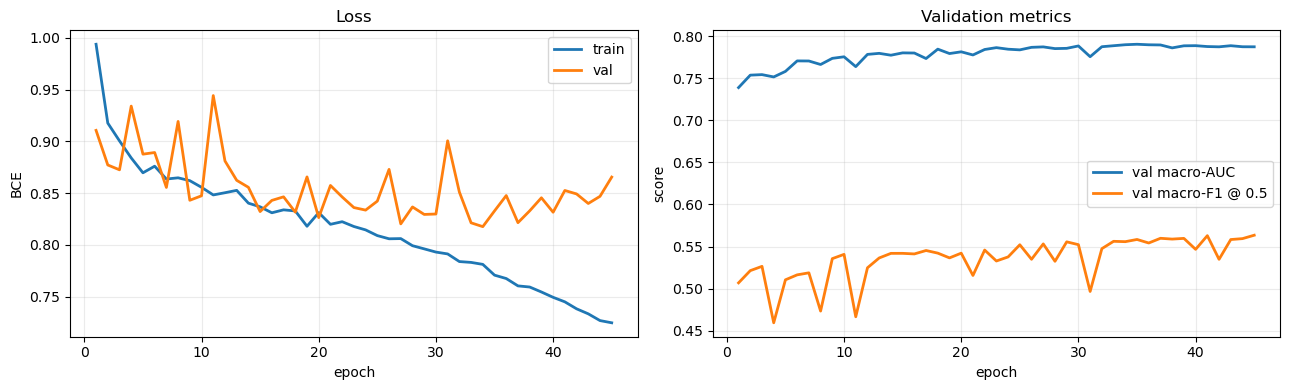

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.epochs, history.train_loss, label='train', lw=2)
axes[0].plot(history.epochs, history.val_loss, label='val', lw=2)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('BCE'); axes[0].set_title('Loss')
axes[0].grid(alpha=0.25); axes[0].legend()

axes[1].plot(history.epochs, history.val_macro_auc, label='val macro-AUC', lw=2)
axes[1].plot(history.epochs, history.val_macro_f1_at_05, label='val macro-F1 @ 0.5', lw=2)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('score'); axes[1].set_title('Validation metrics')
axes[1].grid(alpha=0.25); axes[1].legend()
plt.tight_layout(); plt.show()

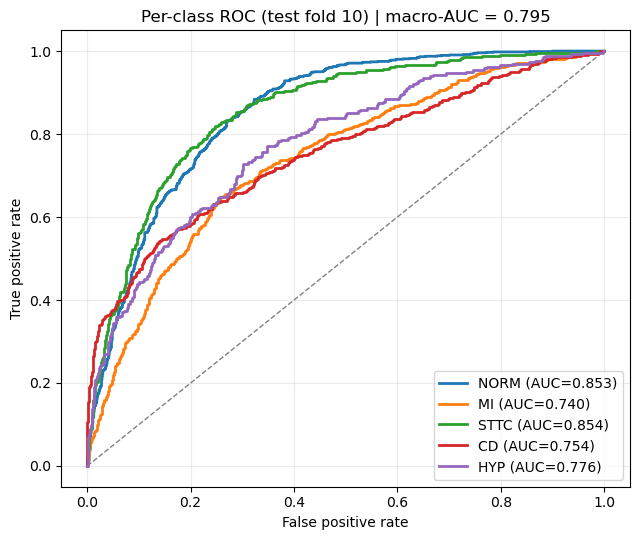

In [8]:
scores = results['test_sigmoid_scores']
labels = results['test_true_labels']

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot([0, 1], [0, 1], lw=1, ls='--', color='grey')
for class_index, class_name in enumerate(SUPER_CLASSES):
    true = labels[:, class_index]
    if len(np.unique(true)) < 2:
        continue
    fpr, tpr, _ = roc_curve(true, scores[:, class_index])
    auc = results['test_per_class_auc'][class_name]
    ax.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC={auc:.3f})')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title(f"Per-class ROC (test fold 10) | macro-AUC = {results['test_macro_auc']:.3f}")
ax.grid(alpha=0.25); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

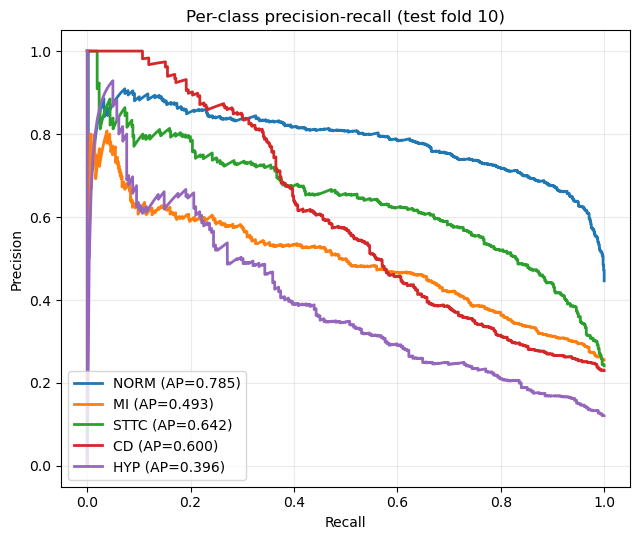

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for class_index, class_name in enumerate(SUPER_CLASSES):
    true = labels[:, class_index]
    if len(np.unique(true)) < 2:
        continue
    precision, recall, _ = precision_recall_curve(true, scores[:, class_index])
    ap = next(row['ap'] for row in results['test_per_class_report'] if row['class'] == class_name)
    ax.plot(recall, precision, lw=2, label=f'{class_name} (AP={ap:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_title('Per-class precision-recall (test fold 10)')
ax.grid(alpha=0.25); ax.legend(loc='lower left')
plt.tight_layout(); plt.show()

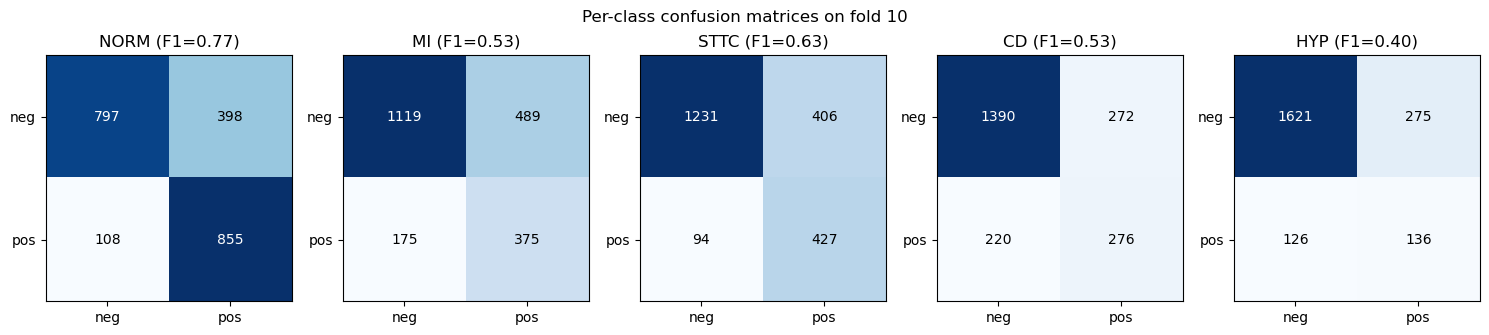

In [10]:
fig, axes = plt.subplots(1, len(SUPER_CLASSES), figsize=(3 * len(SUPER_CLASSES), 3.2))
for ax, row in zip(axes, results['test_per_class_report']):
    cm = np.asarray(row['confusion_matrix'])
    im = ax.imshow(cm, cmap='Blues')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['neg', 'pos']); ax.set_yticklabels(['neg', 'pos'])
    ax.set_title(f"{row['class']} (F1={row['f1']:.2f})")
fig.suptitle('Per-class confusion matrices on fold 10')
plt.tight_layout(); plt.show()

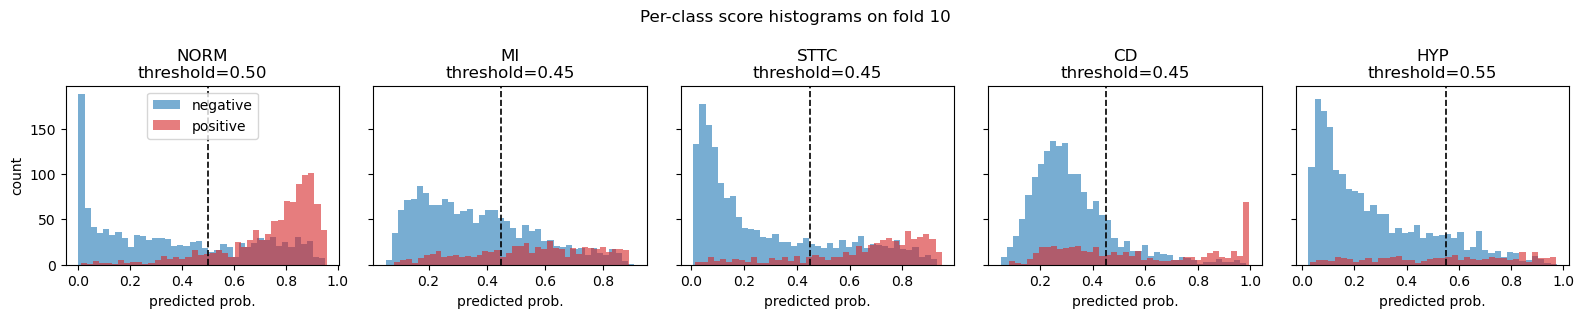

In [11]:
fig, axes = plt.subplots(1, len(SUPER_CLASSES), figsize=(3.2 * len(SUPER_CLASSES), 3.2), sharey=True)
for ax, class_index in zip(axes, range(len(SUPER_CLASSES))):
    class_name = SUPER_CLASSES[class_index]
    threshold = results['thresholds'][class_name]
    positives = scores[labels[:, class_index] == 1, class_index]
    negatives = scores[labels[:, class_index] == 0, class_index]
    ax.hist(negatives, bins=40, alpha=0.6, label='negative', color='tab:blue')
    ax.hist(positives, bins=40, alpha=0.6, label='positive', color='tab:red')
    ax.axvline(threshold, color='black', ls='--', lw=1.2)
    ax.set_title(f"{class_name}\nthreshold={threshold:.2f}")
    ax.set_xlabel('predicted prob.')
axes[0].set_ylabel('count')
axes[0].legend(loc='upper center')
fig.suptitle('Per-class score histograms on fold 10')
plt.tight_layout(); plt.show()

## 6. Save artifacts

In [12]:
import json

OUT_DIR = REPO_ROOT / 'src' / 'data' / 'transformer_vjepa_multilabel'
OUT_DIR.mkdir(parents=True, exist_ok=True)

torch.save(best_state, OUT_DIR / 'model.pt')
np.savez(
    OUT_DIR / 'test_predictions.npz',
    record_names=np.asarray(results['test_record_names']),
    sigmoid_scores=results['test_sigmoid_scores'],
    true_labels=results['test_true_labels'],
    super_classes=np.asarray(SUPER_CLASSES),
)
summary = {
    'thresholds': results['thresholds'],
    'test_macro_auc': results['test_macro_auc'],
    'test_macro_f1': results['test_macro_f1'],
    'test_per_class_auc': results['test_per_class_auc'],
    'test_per_class_report': results['test_per_class_report'],
    'best_epoch': history.best_epoch,
    'best_val_macro_auc': history.best_val_macro_auc,
    'history': {
        'epochs': history.epochs,
        'train_loss': history.train_loss,
        'val_loss': history.val_loss,
        'val_macro_auc': history.val_macro_auc,
        'val_macro_f1_at_05': history.val_macro_f1_at_05,
    },
}
(OUT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2))
print(f'Saved model, predictions and summary to {OUT_DIR}')

Saved model, predictions and summary to /Users/paolodeidda/Documents/UNI/Master/sem4/Comp Vision/CV_group_J/src/data/transformer_vjepa_multilabel
